Loading data from ../TOPAS_simulation_data/broad_beam_6MV_vel\PS.phsp...
Successfully loaded 1000000 particles.
Plotting histogram with 1000000 particles...


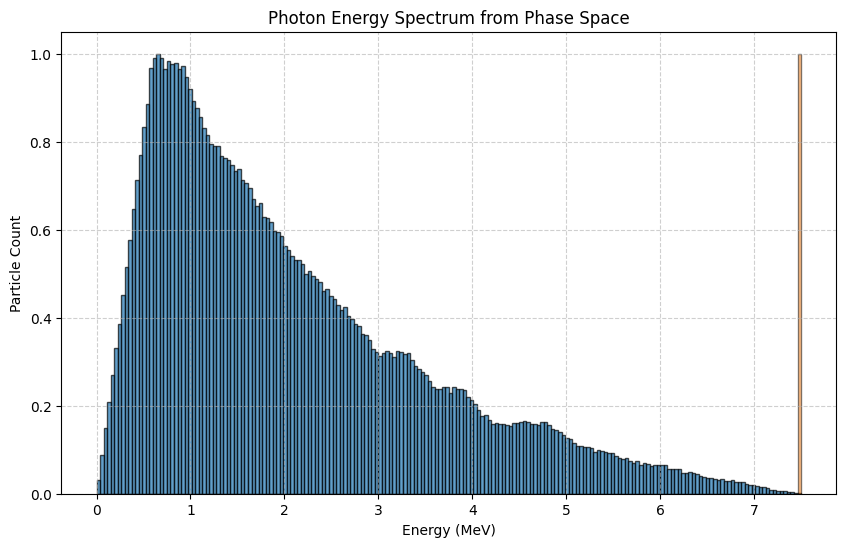

In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
# Set this to the name of your .phsp file
FOLDER = '../TOPAS_simulation_data/broad_beam_6MV_vel'
FOLDER2 = '../TOPAS_simulation_data/broad_beam_6MeV_vel'

PHSP_FILE = os.path.join(FOLDER, 'PS.phsp')
PHSP_FILE2 = os.path.join(FOLDER2, 'PS.phsp')

# Binning parameters (should match your scorer)
BINS = 200
MIN_ENERGY = 0.0  # MeV
MAX_ENERGY = 7.5  # MeV
# ---------------------

print(f"Loading data from {PHSP_FILE}...")

try:
    # Load the phase space data
    # The header says energy is Column 6, which is index 5
    data = np.loadtxt(PHSP_FILE)
    data2 = np.loadtxt(PHSP_FILE2)
    
    # Check if data is 1D (only one particle) or 2D (multiple particles)
    if data.ndim == 1:
        # Only one particle scored, handle as a 1D array
        print("Warning: Only one particle found in the phase space file.")
        if data.size >= 6:
            energies = np.array([data[5]])
            energies2 = np.array([data2[5]])
        else:
            print("Error: Data row is too short.")
            energies = np.array([])
    elif data.shape[1] < 6:
        print(f"Error: Expected at least 6 columns, but found {data.shape[1]}.")
        energies = np.array([])
    else:
        # Extract the 6th column (index 5) which is the Energy
        energies = data[:, 5] / np.max(data[:, 5]) * MAX_ENERGY  # Normalize if needed
        energies2 = data2[:, 5] / np.max(data2[:, 5]) * MAX_ENERGY  # Normalize if needed
        print(f"Successfully loaded {len(energies)} particles.")

    if energies.size > 0:
        print(f"Plotting histogram with {len(energies)} particles...")
        # Create the histogram
        plt.figure(figsize=(10, 6))
        # compute histograms so we can normalize by the max bin height
        counts1, edges = np.histogram(energies, bins=BINS, range=(MIN_ENERGY, MAX_ENERGY))
        counts2, _ = np.histogram(energies2, bins=edges)

        # avoid division by zero
        max1 = counts1.max() if counts1.size else 0
        max2 = counts2.max() if counts2.size else 0

        norm1 = counts1 / max1 if max1 > 0 else counts1
        norm2 = counts2 / max2 if max2 > 0 else counts2

        widths = np.diff(edges)

        # plot normalized histograms (max bin height = 1)
        plt.bar(edges[:-1], norm1, width=widths, align='edge', color='C0', edgecolor='k', alpha=0.7, label='Normalized 6MV')
        plt.bar(edges[:-1], norm2, width=widths, align='edge', color='C1', edgecolor='k', alpha=0.5, label='Normalized 6MeV')
        # Add labels and title
        plt.title('Photon Energy Spectrum from Phase Space')
        plt.xlabel('Energy (MeV)')
        plt.ylabel('Particle Count')
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Show the plot
        plt.show()
    else:
        print("No particle energies to plot.")

except FileNotFoundError:
    print(f"Error: File not found at {PHSP_FILE}")
    print("Please make sure the file name is correct and in the same directory.")
except Exception as e:
    print(f"An error occurred: {e}")
    print("This can happen if the file is empty or formatted incorrectly.")


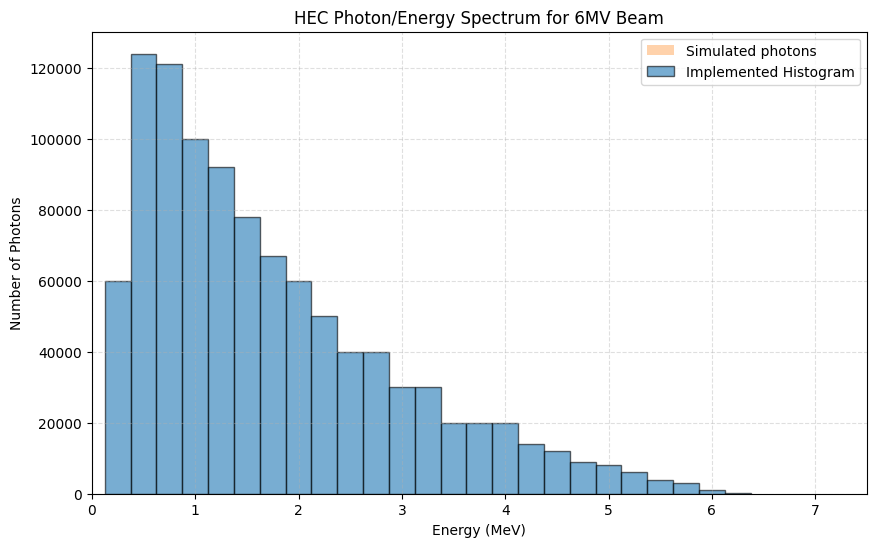

In [11]:
# bin centers and corresponding probabilities/heights (aus deiner Einfügung)
centers = np.array([0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3,
                    3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5, 5.25, 5.5, 5.75, 6, 6.25])
probs = np.array([0.06, 0.124, 0.121, 0.10, 0.092, 0.078, 0.067, 0.06, 0.05, 0.04,
                  0.04, 0.03, 0.03, 0.02, 0.02, 0.02, 0.014, 0.012, 0.009, 0.008,
                  0.006, 0.004, 0.003, 0.001, 0.0001])

# erzeugen der Bin-Kanten aus den Mittelpunkten
midpoints = (centers[:-1] + centers[1:]) / 2
edges = np.empty(len(centers) + 1)
edges[1:-1] = midpoints
edges[0] = centers[0] - (midpoints[0] - centers[0])
edges[-1] = centers[-1] + (centers[-1] - midpoints[-1])
widths = np.diff(edges)

# Wahrscheinlichkeiten -> Counts (auf die vorhandene Datenmenge skalieren)
counts = probs * len(energies)

# Plot
plt.figure(figsize=(10,6))
plt.bar(edges[:-1], counts, width=widths, align='edge', edgecolor='k', alpha=0.6, label='Implemented Histogram')
# optional: tatsächliches Histogramm der energies zur Gegenprüfung
plt.hist(energies, bins=edges, alpha=0.35, color='C1', label='Simulated photons', edgecolor='none')

plt.title('HEC Photon/Energy Spectrum for 6MV Beam')
plt.xlabel('Energy (MeV)')
plt.ylabel('Number of Photons')
plt.xlim(MIN_ENERGY, MAX_ENERGY)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()